# Seaborn ile Veri Görselleştirme: Otomobil Veri Seti Analizi

## 🎯 Dersin Amacı

Bu derste, **Seaborn** kütüphanesini kullanarak elimizdeki otomobil veri setini görselleştireceğiz. 
Veri setimiz; araçların **fiyatı, beygir gücü, yakıt tipi, segmenti** gibi teknik ve kategorik özellikleri içermektedir.

**Amacımız:** Ham veriden anlamlı grafikler oluşturarak, "Hangi özellik fiyatı artırıyor?", "Hangi segment daha hızlı?", "Yakıt tipi performansı nasıl etkiliyor?" gibi sorulara yanıt bulmak.

## 📚 Bu Derste Öğrenecekleriniz:

1. **lmplot**: İki değişken arasındaki ilişkiyi görselleştirme ve trend analizi
2. **boxplot**: Kategorik değişkenlere göre sayısal verilerin dağılımını analiz etme
3. **violinplot**: Veri yoğunluğunu detaylı inceleme ve dağılım karşılaştırması
4. **melt**: Veriyi uzun formata dönüştürme ve karşılaştırma için hazırlama
5. **heatmap**: Korelasyon analizi ve değişkenler arası ilişki haritası
6. **histplot**: Tek değişkenin dağılımını inceleme ve yoğunluk eğrisi
7. **countplot**: Kategorik verilerin frekansını görselleştirme
8. **jointplot**: İki değişkenin birlikte analizi (scatter + histogram kombinasyonu)

## 🔧 Ön Gereksinimler

- Python 3.x
- Pandas kütüphanesi (veri manipülasyonu için)
- Matplotlib kütüphanesi (görselleştirme altyapısı)
- Seaborn kütüphanesi (istatistiksel görselleştirme)

## 📊 Veri Seti Hakkında

Bu derste kullanacağımız `cars.csv` dosyası şu bilgileri içermektedir:
- **200 adet** otomobil verisi
- **13 farklı özellik** (Marka, Model, Segment, Yakıt Tipi, Motor Hacmi, Beygir, Tork, vb.)
- **Farklı segmentler**: Hatchback, Sedan, SUV, Spor
- **Farklı yakıt tipleri**: Benzin, Dizel, Elektrik, Hibrit

In [2]:
# Gerekli kütüphaneleri içe aktarıyoruz
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings 

# Grafiklerin daha temiz görünmesi için uyarıları kapatıyoruz
# Bu, bazı eski fonksiyonlar için çıkan uyarıları gizler
warnings.filterwarnings('ignore')

# ============================================
# SEABORN STİL AYARLARI
# ============================================
# Seaborn'un varsayılan stilini ve renk paletini ayarlıyoruz
sns.set_style('whitegrid')  # Arka plana hafif çizgiler ekler, profesyonel görünüm sağlar
# Diğer stil seçenekleri:
# - 'darkgrid': Koyu arka plan, açık çizgiler
# - 'white': Beyaz arka plan, çizgi yok
# - 'dark': Koyu arka plan, çizgi yok
# - 'ticks': Beyaz arka plan, sadece eksen işaretleri

# ============================================
# MATPLOTLIB GENEL AYARLARI
# ============================================
plt.rcParams['figure.figsize'] = (10, 6)  # Tüm grafiklerin varsayılan boyutunu ayarlar (genişlik, yükseklik)
plt.rcParams['font.size'] = 10  # Varsayılan font boyutu
plt.rcParams['figure.dpi'] = 100  # Grafik çözünürlüğü (dots per inch)

# Kütüphane versiyonlarını kontrol ediyoruz
print(f"Seaborn: {sns.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")

Seaborn: 0.13.2
Pandas: 2.3.3
Matplotlib: 3.10.8


In [3]:
# ============================================
# VERİ YÜKLEME VE ÖN İŞLEME
# ============================================

# Veri setini CSV dosyasından okuyoruz
# index_col=0 parametresi, 'ID' sütununu satır indeksi olarak kullanmamızı sağlar.
# Bu sayede ID sütunu ayrı bir sütun olarak görünmez, direkt indeks olur.
df = pd.read_csv("cars.csv", index_col=0)

# ============================================
# VERİ TEMİZLEME: Fiyat Sütunu
# ============================================
# Fiyat sütunundaki binlik ayırıcı noktaları (.) temizleyip sayısal veriye çeviriyoruz
# Örnek: "1.250.000" -> 1250000
# Eğer bu işlemi yapmazsak, pandas fiyatları string olarak algılar ve grafiklerde yanlış görünür.
if df['Fiyat_TL'].dtype == 'O':  # 'O' = object (string) tipi demektir
    df['Fiyat_TL'] = df['Fiyat_TL'].astype(str).str.replace('.', '').astype(int)

# Veri seti hakkında genel bilgiler
print(f"Satır sayısı: {len(df)}")
print(f"Sütun sayısı: {len(df.columns)}")
print(f"\nSütunlar: {', '.join(df.columns.tolist())}")
print(f"\nSegment: {df['Segment'].unique()}")
print(f"Yakıt Tipi: {df['Yakit_Tipi'].unique()}")
print(f"Garanti: {df['Garanti'].unique()}")

df.head()

Satır sayısı: 200
Sütun sayısı: 13

Sütunlar: Marka, Model, Segment, Yakit_Tipi, Motor_Hacmi, Beygir, Tork, 0_100_Hizlanma, Maks_Hiz, Ort_Yakit, Yil, Garanti, Fiyat_TL

Segment: ['Hatchback' 'Spor' 'Sedan' 'SUV' 'Kamyonet']
Yakıt Tipi: ['Benzin' 'Elektrik' 'Dizel' 'Hibrit' 'LPG']
Garanti: ['Yok' 'Var']


,Marka,Model,Segment,Yakit_Tipi,Motor_Hacmi,Beygir,Tork,0_100_Hizlanma,Maks_Hiz,Ort_Yakit,Yil,Garanti,Fiyat_TL
ID,,,,,,,,,,,,,
1,Citroen,C3,Hatchback,Benzin,1.7,88,105,18.2,189,3.9,2020,Yok,1250000
2,Dacia,Sandero,Hatchback,Benzin,1.4,69,82,22.8,183,3.5,2024,Var,1450000
3,Ferrari,296 GTB,Spor,Benzin,3.7,995,1194,2.5,340,37.3,2020,Yok,58500000
4,Tesla,Model S,Sedan,Elektrik,0.0,243,364,6.7,241,0.0,2022,Yok,4800000
5,Audi,Q7,SUV,Benzin,1.3,210,252,7.4,230,9.2,2023,Var,9500000


## 1. İki Değişken Arasındaki İlişkiyi İncelemek (lmplot)

### 🎯 Senaryo
Araçların **Beygir Gücü (HP)** arttıkça **Fiyatı** nasıl değişiyor? Bu ilişkiyi görselleştirmek için `lmplot` kullanacağız.

### 📖 lmplot Nedir?
`lmplot` (linear model plot), iki değişken arasındaki ilişkiyi gösteren güçlü bir fonksiyondur. Bu fonksiyon:
- **Scatter plot** (dağılım grafiği) oluşturur
- İsteğe bağlı olarak **regresyon doğrusu** (trend line) ekler
- Kategorik değişkenlere göre **renk ayrımı** yapabilir
- **Alt grafikler** (subplots) oluşturabilir

### 📌 Önemli Parametreler:
* **x:** X ekseni değişkeni (ör: Beygir)
* **y:** Y ekseni değişkeni (ör: Fiyat_TL)
* **hue:** Veriyi 3. bir boyuta göre renklendirir (kategorik ayrım için)
* **fit_reg:** Regresyon doğrusunu gösterir/gizler (True/False)
* **height/aspect:** Grafik boyutlarını kontrol eder
* **palette:** Renk paletini belirler

### 💡 Ne Zaman Kullanılır?
- ✅ İki sayısal değişken arasındaki ilişkiyi görmek istediğinizde
- ✅ Kategorik bir değişkene göre ilişkiyi ayırmak istediğinizde
- ✅ Eğilim çizgisi (trend line) eklemek istediğinizde
- ✅ Korelasyon analizi yapmak istediğinizde

### 🔍 Yorumlama İpuçları:
- **Pozitif eğim:** X artarken Y de artar (pozitif korelasyon)
- **Negatif eğim:** X artarken Y azalır (negatif korelasyon)
- **Dikey dağılım:** Y değişkeninde yüksek varyans var
- **Yatay dağılım:** X değişkeninde yüksek varyans var

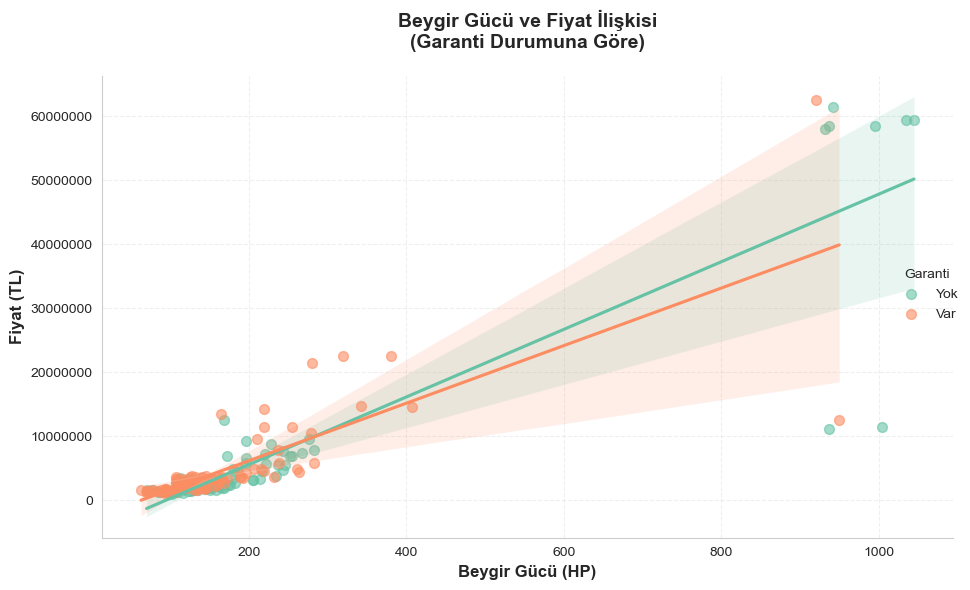

In [4]:
# ============================================
# ÖRNEK 1: Beygir Gücü ve Fiyat İlişkisi
# ============================================

# fit_reg=False: Regresyon doğrusunu (trend çizgisini) kaldırır, sadece noktaları gösterir.
# Bu sayede veri noktalarını daha net görebiliriz.
# hue='Garanti': Garantisi olan ve olmayan araçları farklı renklerde gösterir.
# Bu parametre ile kategorik bir değişkene göre veriyi ayırabiliriz.

sns.lmplot(x='Beygir', y='Fiyat_TL', data=df, 
           fit_reg=True,  # Regresyon doğrusunu gizle
           hue='Garanti',  # Garanti durumuna göre renklendir
           height=6,  # Grafik yüksekliği (inç)
           aspect=1.5,  # Genişlik/yükseklik oranı (1.5 = daha geniş)
           palette='Set2',  # Renk paleti (Set2: yumuşak, profesyonel renkler)
           scatter_kws={'s': 50, 'alpha': 0.6})  # Nokta boyutu ve şeffaflık

# Eksen başlıklarını ve grafik başlığını düzenleyelim
plt.title('Beygir Gücü ve Fiyat İlişkisi\n(Garanti Durumuna Göre)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Beygir Gücü (HP)', fontsize=12, fontweight='bold')
plt.ylabel('Fiyat (TL)', fontsize=12, fontweight='bold')

# Fiyat eksenindeki sayıları düzgün göstermek için (Bilimsel gösterimi kapatır)
# Örnek: 1e7 yerine 10.000.000 gösterir
plt.ticklabel_format(style='plain', axis='y')

# Grid'i daha belirgin yapalım
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()  # Grafik elemanlarının taşmasını önler
plt.show()



## 2. Kategorik Değişkenlere Göre Dağılım Analizi (Boxplot)

### 🎯 Senaryo
Farklı **segmentlerdeki** araçların **fiyat dağılımı** nasıl? Hangi segment daha pahalı?

### 📖 Boxplot Nedir?
Boxplot (kutu grafiği), bir kategorik değişkene göre sayısal bir değişkenin dağılımını gösteren istatistiksel bir grafik türüdür.

### 📊 Boxplot'un Bileşenleri:
1. **Kutunun içindeki çizgi:** **Medyan** (ortanca) değeri gösterir - verinin %50'si bu değerin altında
2. **Kutunun alt kenarı:** **1. çeyrek** (Q1) - verinin %25'i bu değerin altında
3. **Kutunun üst kenarı:** **3. çeyrek** (Q3) - verinin %75'i bu değerin altında
4. **Kutunun altındaki çizgi:** **Minimum** değer (Q1 - 1.5*IQR'ın altındaki en yakın değer)
5. **Kutunun üstündeki çizgi:** **Maksimum** değer (Q3 + 1.5*IQR'ın üstündeki en yakın değer)
6. **Noktalar:** **Aykırı değerler** (outliers) - normal dağılımın dışındaki değerler

**IQR (Interquartile Range) = Q3 - Q1** (çeyrekler arası aralık)

### 💡 Ne Zaman Kullanılır?
- ✅ Kategorilere göre sayısal değerlerin dağılımını karşılaştırmak için
- ✅ Aykırı değerleri tespit etmek için
- ✅ Medyan ve çeyrek değerleri hızlıca görmek için
- ✅ Verinin simetrik olup olmadığını anlamak için
- ✅ Kategoriler arası farklılıkları görmek için

### 🔍 Yorumlama İpuçları:
- **Uzun kutu:** Yüksek varyans (değerler geniş aralıkta dağılmış)
- **Kısa kutu:** Düşük varyans (değerler birbirine yakın)
- **Medyan yukarıda:** Pozitif çarpıklık (sağa çarpık)
- **Medyan aşağıda:** Negatif çarpıklık (sola çarpık)

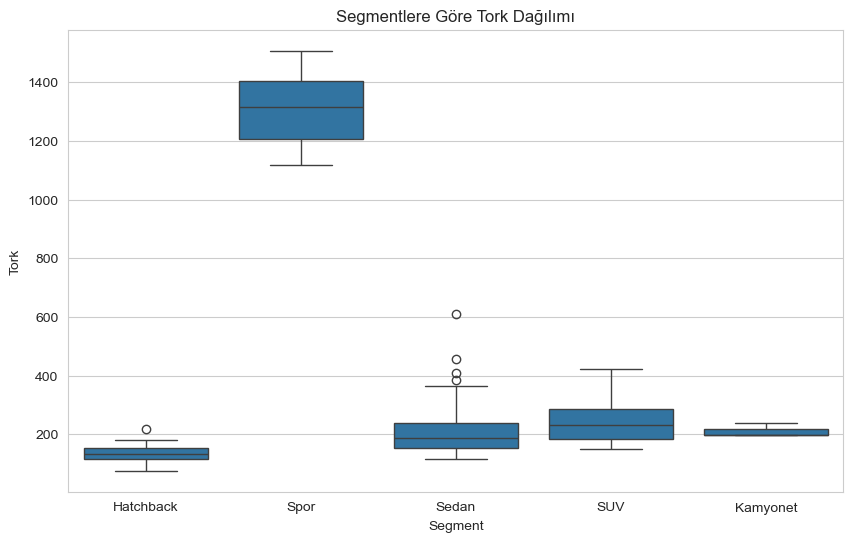

In [5]:


# Boxplot çizimi
sns.boxplot(x="Segment", y="Tork", data=df)
plt.title("Segmentlere Göre Tork Dağılımı")
plt.show()


## 3. Yoğunluk ve Dağılım (Violin Plot)

### 🎯 Senaryo
Farklı **yakıt tiplerindeki** araçların **beygir gücü dağılımı** nasıl? Hangi yakıt tipi daha güçlü motorlara sahip?

### 📖 Violin Plot Nedir?
Violin plot, boxplot'un daha gelişmiş halidir. Verinin nerede yoğunlaştığını (yoğunluk dağılımını) gösterir. 
Keman şeklindeki grafik, verinin hangi değerlerde daha sık görüldüğünü görsel olarak ifade eder.

### 📊 Violin Plot'un Avantajları:
- ✅ **Yoğunluk bilgisi:** Verinin hangi değerlerde yoğunlaştığını gösterir
- ✅ **Dağılım şekli:** Verinin normal, çarpık veya çok modlu olup olmadığını gösterir
- ✅ **Boxplot bilgisi:** İsteğe bağlı olarak boxplot bilgilerini de içerebilir

### 💡 Ne Zaman Kullanılır?
- ✅ Verinin yoğunluk dağılımını detaylı görmek istediğinizde
- ✅ Boxplot'tan daha fazla bilgi almak istediğinizde
- ✅ Verinin çok modlu (birden fazla tepe noktası) olup olmadığını anlamak için
- ✅ Kategoriler arası dağılım farklılıklarını detaylı incelemek için

### 🔍 Yorumlama İpuçları:
- **Geniş bölgeler:** O değerlerde daha fazla veri var
- **Dar bölgeler:** O değerlerde daha az veri var
- **Çift tepe:** İki farklı grup var (bimodal dağılım)
- **Asimetrik şekil:** Veri çarpık dağılmış

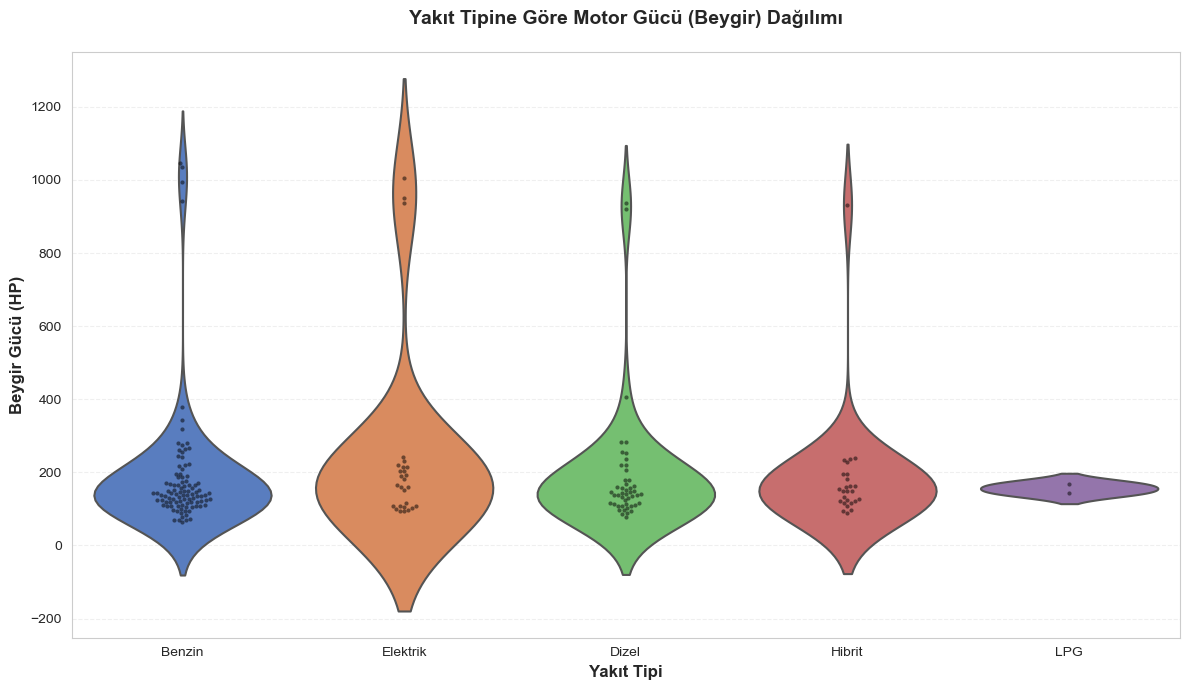

In [14]:
# ============================================
# ÖRNEK 2: Yakıt Tipine Göre Beygir Gücü Dağılımı
# ============================================

plt.figure(figsize=(12, 7))

# inner=None: İçindeki kutu grafiğini (boxplot) kaldırır, sadece dış hatları (violin) çizer
# Bu sayede daha temiz ve sade bir görünüm elde ederiz
sns.violinplot(x='Yakit_Tipi', y='Beygir', data=df, 
               palette='muted',  # Yumuşak, profesyonel renkler
               inner=None,  # İç kutu grafiğini kaldır
               linewidth=1.5)  # Çizgi kalınlığı

# Üzerine bir de Swarmplot (noktalar) ekleyelim ki gerçek veri dağılımını görelim
# Swarmplot, her veri noktasını gösterir ve çakışmaları önler
sns.swarmplot(x='Yakit_Tipi', y='Beygir', data=df, 
              color='black',  # Siyah renk (k = black kısaltması)
              alpha=0.5,  # Şeffaflık (0.5 = %50 opak)
              size=3)  # Nokta boyutu

# Grafik başlığı ve eksen etiketleri
plt.title('Yakıt Tipine Göre Motor Gücü (Beygir) Dağılımı', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Yakıt Tipi', fontsize=12, fontweight='bold')
plt.ylabel('Beygir Gücü (HP)', fontsize=12, fontweight='bold')

# Grid ekleyelim
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()



## 4. Veriyi Karşılaştırma İçin Dönüştürme (Melt)

### 🎯 Senaryo
**Beygir** ve **Tork** değerlerini aynı grafikte karşılaştırmak istiyoruz. Bu iki farklı özelliği tek bir grafikte göstermek için veriyi dönüştürmemiz gerekiyor.

### 📖 Melt Fonksiyonu Nedir?
Pandas'ın `melt` fonksiyonu, veriyi **geniş formattan** (wide format) **uzun formata** (long format) çevirir.

**Geniş Format (Wide):**
```
| Marka | Model | Beygir | Tork |
|-------|-------|--------|------|
| Audi  | A4    | 200    | 300  |
```

**Uzun Format (Long):**
```
| Marka | Model | Özellik | Değer |
|-------|-------|---------|-------|
| Audi  | A4    | Beygir  | 200   |
| Audi  | A4    | Tork    | 300   |
```

### 💡 Ne Zaman Kullanılır?
- ✅ Birden fazla sayısal sütunu aynı grafikte karşılaştırmak için
- ✅ Seaborn'un bazı fonksiyonları uzun format veri bekler
- ✅ Veriyi daha analiz edilebilir hale getirmek için
- ✅ Kategorik karşılaştırmalar yapmak için

### 🔧 Melt Parametreleri:
- **id_vars:** Sabit kalacak sütunlar (Marka, Model, Segment vb.)
- **value_vars:** Dönüştürülecek sütunlar (Beygir, Tork vb.) - belirtilmezse diğer tüm sütunlar
- **var_name:** Yeni kategori sütununun adı (varsayılan: 'variable')
- **value_name:** Yeni değer sütununun adı (varsayılan: 'value')

In [7]:
# ============================================
# VERİ DÖNÜŞTÜRME: Melt İşlemi
# ============================================

# Sadece ilgilendiğimiz sütunları seçelim
# Bu işlem, gereksiz sütunları kaldırarak işlemi hızlandırır
stats_df = df[['Marka', 'Model', 'Segment', 'Beygir', 'Tork']]

print("Orijinal veri:")
print(stats_df.head(3))
print(f"Şekil: {stats_df.shape}")

# Melt işlemi: Beygir ve Tork sütunlarını "Ozellik" adlı tek bir sütuna indiriyoruz
melted_df = pd.melt(stats_df, 
                    id_vars=["Marka", "Model", "Segment"],
                    value_vars=["Beygir", "Tork"],
                    var_name="Ozellik",
                    value_name="Deger")

print("\nDönüştürülmüş veri:")
print(melted_df.head(6))
print(f"Şekil: {melted_df.shape}")

Orijinal veri:
      Marka    Model    Segment  Beygir  Tork
ID                                           
1   Citroen       C3  Hatchback      88   105
2     Dacia  Sandero  Hatchback      69    82
3   Ferrari  296 GTB       Spor     995  1194
Şekil: (200, 5)

Dönüştürülmüş veri:
     Marka    Model    Segment Ozellik  Deger
0  Citroen       C3  Hatchback  Beygir     88
1    Dacia  Sandero  Hatchback  Beygir     69
2  Ferrari  296 GTB       Spor  Beygir    995
3    Tesla  Model S      Sedan  Beygir    243
4     Audi       Q7        SUV  Beygir    210
5     Fiat      500  Hatchback  Beygir    109
Şekil: (400, 5)


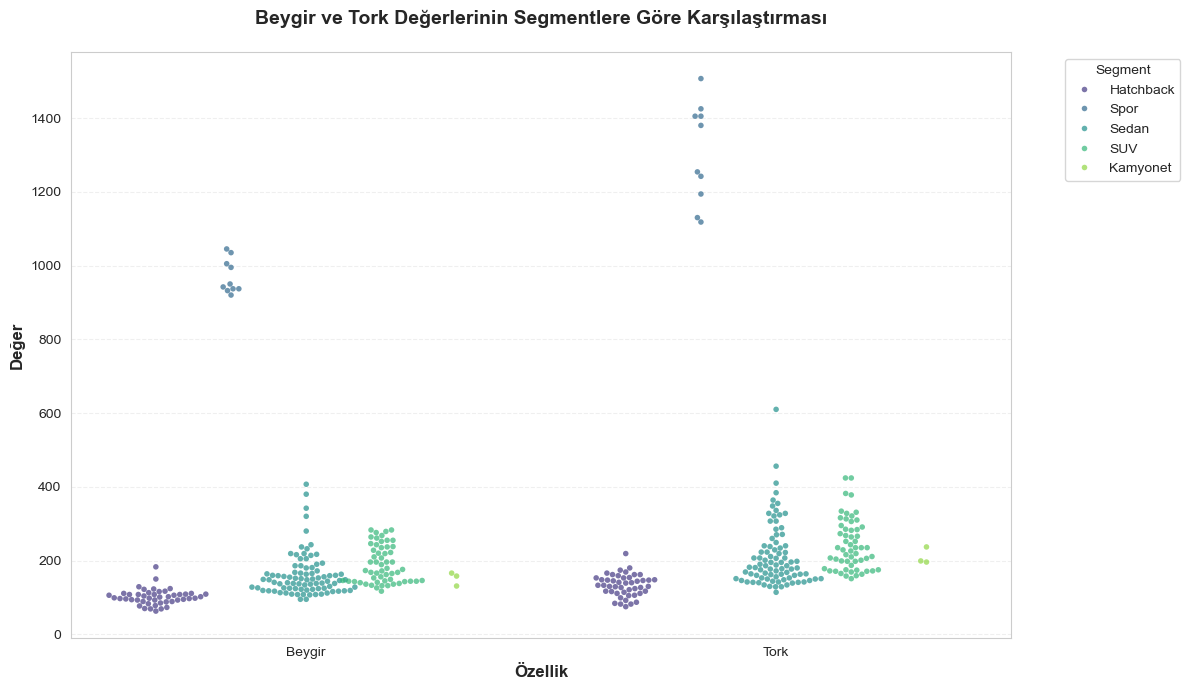

In [8]:
# ============================================
# ÖRNEK 3: Beygir ve Tork Karşılaştırması
# ============================================

plt.figure(figsize=(12, 7))

# Özellik (Beygir/Tork) ve Değer arasındaki ilişki
# hue='Segment': Segmentlere göre renk ayrımı yapıyoruz
# dodge=True: Kategorileri yan yana ayırır, üst üste binmesini engeller
# Bu sayede her segment için ayrı nokta grupları görürüz

sns.swarmplot(x='Ozellik', y='Deger', data=melted_df, 
              hue='Segment',  # Segmentlere göre renklendir
              dodge=True,  # Kategorileri yan yana yerleştir
              palette='viridis',  # Renk paleti (yeşil-mor tonları)
              size=4,  # Nokta boyutu
              alpha=0.7)  # Şeffaflık

# Grafik başlığı ve eksen etiketleri
plt.title('Beygir ve Tork Değerlerinin Segmentlere Göre Karşılaştırması', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Özellik', fontsize=12, fontweight='bold')
plt.ylabel('Değer', fontsize=12, fontweight='bold')

# Lejantı grafiğin dışına alır (bbox_to_anchor ile konumlandırma)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Segment')

# Grid ekleyelim
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()



## 5. İlişkilerin Sıcaklık Haritası (Heatmap)

### 🎯 Senaryo
Veri setindeki tüm sayısal özelliklerin birbirleriyle olan ilişkisini tek bakışta görmek istiyoruz. 
Hangi özellikler birbiriyle güçlü ilişki içinde?

### 📖 Heatmap Nedir?
Heatmap (ısı haritası), korelasyon matrisini görselleştirmek için kullanılan bir grafik türüdür. 
Her hücre, iki değişken arasındaki korelasyon katsayısını renk ve sayı ile gösterir.

### 📊 Korelasyon Katsayısı:
Korelasyon katsayısı **-1 ile +1** arasında değer alır:
* **+1'e yakın:** Güçlü pozitif ilişki (Biri artarsa diğeri de artar)
* **0'a yakın:** Zayıf ilişki (İlişki yok)
* **-1'e yakın:** Güçlü negatif ilişki (Biri artarsa diğeri azalır)

### 💡 Ne Zaman Kullanılır?
- ✅ Çok sayıda değişken arasındaki ilişkileri tek bakışta görmek için
- ✅ Korelasyon analizi yapmak için
- ✅ Hangi özelliklerin birbiriyle ilişkili olduğunu bulmak için
- ✅ Veri keşfi (exploratory data analysis) aşamasında

### 🎨 Renk Yorumlama:
- **Kırmızı tonları:** Pozitif korelasyon (koyu kırmızı = güçlü pozitif)
- **Mavi tonları:** Negatif korelasyon (koyu mavi = güçlü negatif)
- **Açık renkler:** Zayıf korelasyon

### 🔍 Yorumlama İpuçları:
- Köşegen üzerindeki değerler her zaman **1.0**'dır (bir değişken kendisiyle %100 ilişkilidir)
- Simetrik bir matristir (A-B korelasyonu = B-A korelasyonu)
- **0.7'den büyük:** Güçlü pozitif ilişki
- **-0.7'den küçük:** Güçlü negatif ilişki

                Motor_Hacmi    Beygir      Tork  0_100_Hizlanma  Maks_Hiz  \
Motor_Hacmi        1.000000  0.285878  0.212694       -0.098485  0.251106   
Beygir             0.285878  1.000000  0.987509       -0.692446  0.958043   
Tork               0.212694  0.987509  1.000000       -0.685729  0.947069   
0_100_Hizlanma    -0.098485 -0.692446 -0.685729        1.000000 -0.831823   
Maks_Hiz           0.251106  0.958043  0.947069       -0.831823  1.000000   
Ort_Yakit          0.735717  0.712295  0.626925       -0.482934  0.691625   
Yil               -0.213452 -0.148402 -0.117042        0.128293 -0.127435   
Fiyat_TL           0.473930  0.869601  0.821432       -0.566215  0.828097   

                Ort_Yakit       Yil  Fiyat_TL  
Motor_Hacmi      0.735717 -0.213452  0.473930  
Beygir           0.712295 -0.148402  0.869601  
Tork             0.626925 -0.117042  0.821432  
0_100_Hizlanma  -0.482934  0.128293 -0.566215  
Maks_Hiz         0.691625 -0.127435  0.828097  
Ort_Yakit        1

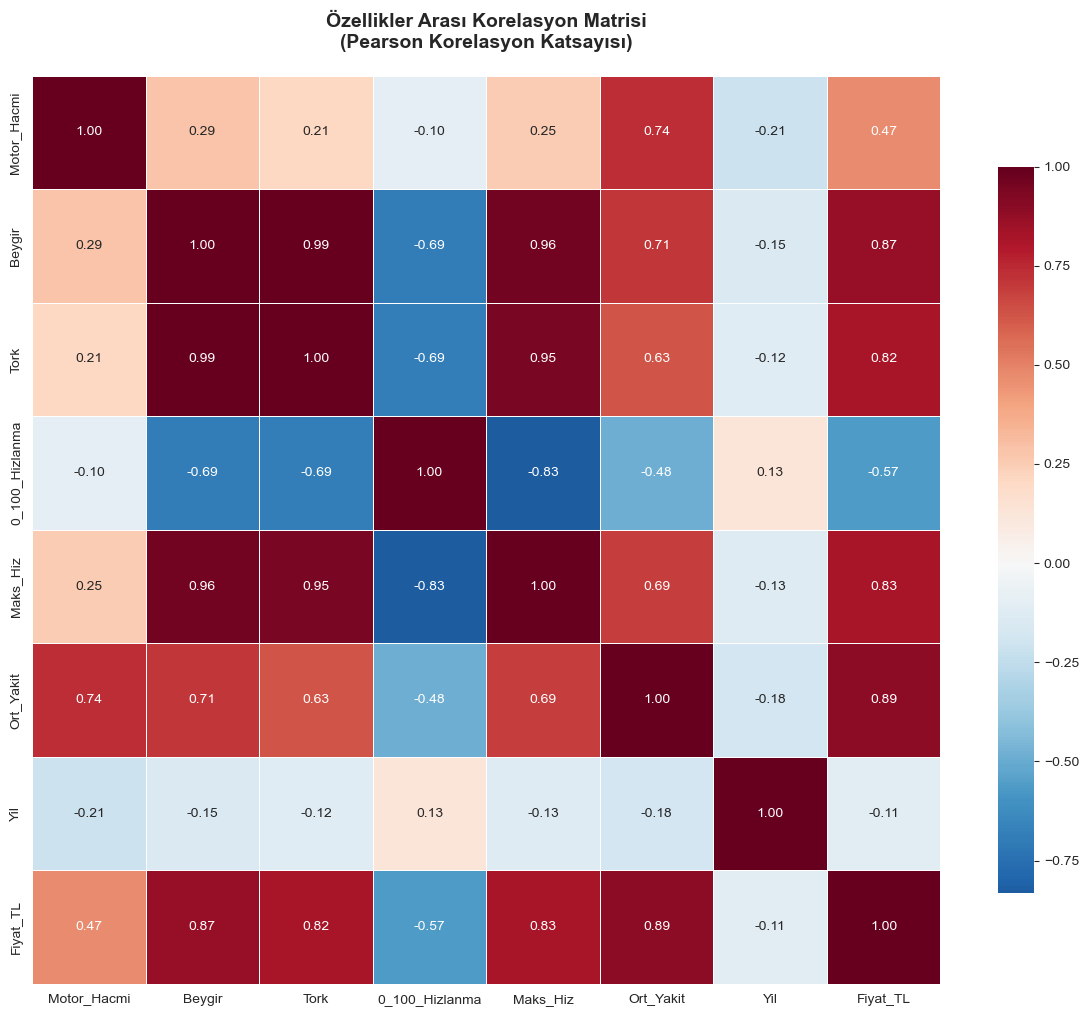


En yüksek 5 korelasyon:
Beygir - Tork: 0.988
Tork - Beygir: 0.988
Beygir - Maks_Hiz: 0.958
Maks_Hiz - Beygir: 0.958
Tork - Maks_Hiz: 0.947


In [16]:
# ============================================
# ÖRNEK 4: Korelasyon Heatmap
# ============================================

# Sadece sayısal sütunları seçiyoruz
# Kategorik sütunlar (Marka, Model, Segment vb.) korelasyon hesaplamasına dahil edilmez
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Korelasyon matrisini hesaplıyoruz
# corr() fonksiyonu, Pearson korelasyon katsayısını hesaplar
corr = numeric_df.corr()
print(corr)
# Isı haritasını çiziyoruz
plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            annot=True,  # Kutuların içine sayıları yazar
            fmt=".2f",  # Sayı formatı (2 ondalık basamak)
            cmap='RdBu_r',  # Kırmızı-Mavi renk haritası (Red-Blue reverse)
            center=0,  # Renk haritasının merkezi (0 = nötr)
            square=True,  # Kare hücreler
            linewidths=0.5,  # Hücreler arası çizgi kalınlığı
            cbar_kws={"shrink": 0.8})  # Renk çubuğu (colorbar) ayarları

plt.title('Özellikler Arası Korelasyon Matrisi\n(Pearson Korelasyon Katsayısı)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# En yüksek korelasyonları bulalım
corr_unstacked = corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1.0]
top_correlations = corr_unstacked.abs().sort_values(ascending=False).head(5)

print("\nEn yüksek 5 korelasyon:")
for (var1, var2), value in top_correlations.items():
    original_value = corr.loc[var1, var2]
    print(f"{var1} - {var2}: {original_value:.3f}")

## 6. Tek Bir Özelliğin Dağılımı (Histplot)

### 🎯 Senaryo
Araçların **0-100 km/h hızlanma süreleri** nasıl dağılmış? Çoğu araç ne kadar sürede hızlanıyor?

### 📖 Histplot Nedir?
`histplot` (histogram plot), tek bir sayısal değişkenin dağılımını gösteren grafik türüdür. 
Veriyi belirli aralıklara (bins) böler ve her aralıktaki veri sayısını gösterir.

### ⚠️ Önemli Not:
Eski `distplot` fonksiyonu artık kullanımdan kaldırılmıştır (deprecated). 
Bunun yerine modern `histplot` veya `kdeplot` kullanılmalıdır.

### 📊 Histogram Bileşenleri:
- **X ekseni:** Değişkenin değer aralığı
- **Y ekseni:** Her aralıktaki veri sayısı (frekans)
- **Bins:** Veriyi böldüğümüz aralık sayısı
- **KDE (Kernel Density Estimation):** İsteğe bağlı yoğunluk eğrisi

### 💡 Ne Zaman Kullanılır?
- ✅ Tek bir değişkenin dağılımını görmek için
- ✅ Verinin normal dağılıma uyup uymadığını kontrol etmek için
- ✅ Aykırı değerleri tespit etmek için
- ✅ Verinin çarpık olup olmadığını anlamak için

### 🔍 Yorumlama İpuçları:
- **Çan şekli:** Normal dağılım (simetrik)
- **Sağa çarpık:** Çoğu değer düşük, az sayıda yüksek değer var
- **Sola çarpık:** Çoğu değer yüksek, az sayıda düşük değer var
- **Çok modlu:** Birden fazla tepe noktası (farklı gruplar var)

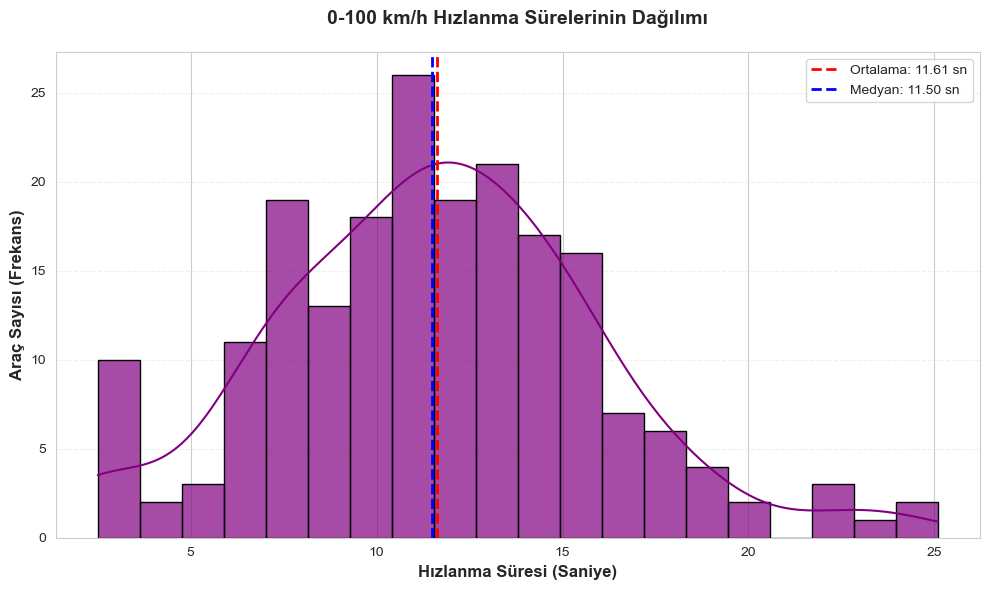


Ortalama: 11.61 sn
Medyan: 11.50 sn
Std Sapma: 4.36 sn
Min: 2.50 sn
Max: 25.10 sn


In [10]:
# ============================================
# ÖRNEK 5: 0-100 Hızlanma Süresi Dağılımı
# ============================================

plt.figure(figsize=(10, 6))

# Hızlanma değerlerinin dağılımı
# kde=True: Histogramın üzerine yoğunluk eğrisini (KDE) ekler
# Bu eğri, verinin teorik dağılımını gösterir
sns.histplot(df['0_100_Hizlanma'], 
             kde=True,  # Yoğunluk eğrisini göster
             color='purple',  # Histogram rengi
             bins=20,  # Aralık sayısı (daha fazla = daha detaylı)
             alpha=0.7,  # Şeffaflık
             edgecolor='black',  # Çubuk kenarları
             linewidth=1)  # Çubuk kenar kalınlığı

# İstatistiksel bilgiler ekleyelim
mean_val = df['0_100_Hizlanma'].mean()
median_val = df['0_100_Hizlanma'].median() 

# Ortalama ve medyan çizgilerini ekle
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
            label=f'Ortalama: {mean_val:.2f} sn')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, 
            label=f'Medyan: {median_val:.2f} sn')

plt.title('0-100 km/h Hızlanma Sürelerinin Dağılımı', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Hızlanma Süresi (Saniye)', fontsize=12, fontweight='bold')
plt.ylabel('Araç Sayısı (Frekans)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

print(f"\nOrtalama: {mean_val:.2f} sn")
print(f"Medyan: {median_val:.2f} sn")
print(f"Std Sapma: {df['0_100_Hizlanma'].std():.2f} sn")
print(f"Min: {df['0_100_Hizlanma'].min():.2f} sn")
print(f"Max: {df['0_100_Hizlanma'].max():.2f} sn")

## 7. Kategorik Verilerin Sayısı (Countplot)

### 🎯 Senaryo
Veri setimizde hangi markalardan kaç tane araç var? Hangi markalar daha fazla temsil ediliyor?

### 📖 Countplot Nedir?
`countplot`, kategorik bir değişkenin her kategorisindeki veri sayısını (frekans) gösteren çubuk grafik türüdür. 
Pandas'ın `value_counts()` fonksiyonunun görsel versiyonudur.

### 📊 Countplot Özellikleri:
- Her kategori için bir çubuk gösterir
- Çubuk yüksekliği, o kategorideki veri sayısını gösterir
- Kategorileri sıralayabilir (frekansa göre, alfabetik vb.)
- Renk paleti ile kategorileri ayırt edebiliriz

### 💡 Ne Zaman Kullanılır?
- ✅ Kategorik değişkenlerin frekansını görmek için
- ✅ Hangi kategorinin daha yaygın olduğunu anlamak için
- ✅ Veri setindeki kategori dağılımını kontrol etmek için
- ✅ Dengesiz veri setlerini tespit etmek için

### 🔍 Yorumlama İpuçları:
- **Yüksek çubuklar:** O kategoride daha fazla veri var
- **Düşük çubuklar:** O kategoride daha az veri var
- **Eşit yükseklikler:** Dengeli dağılım
- **Çok farklı yükseklikler:** Dengesiz dağılım (makine öğrenmesi için sorun olabilir)

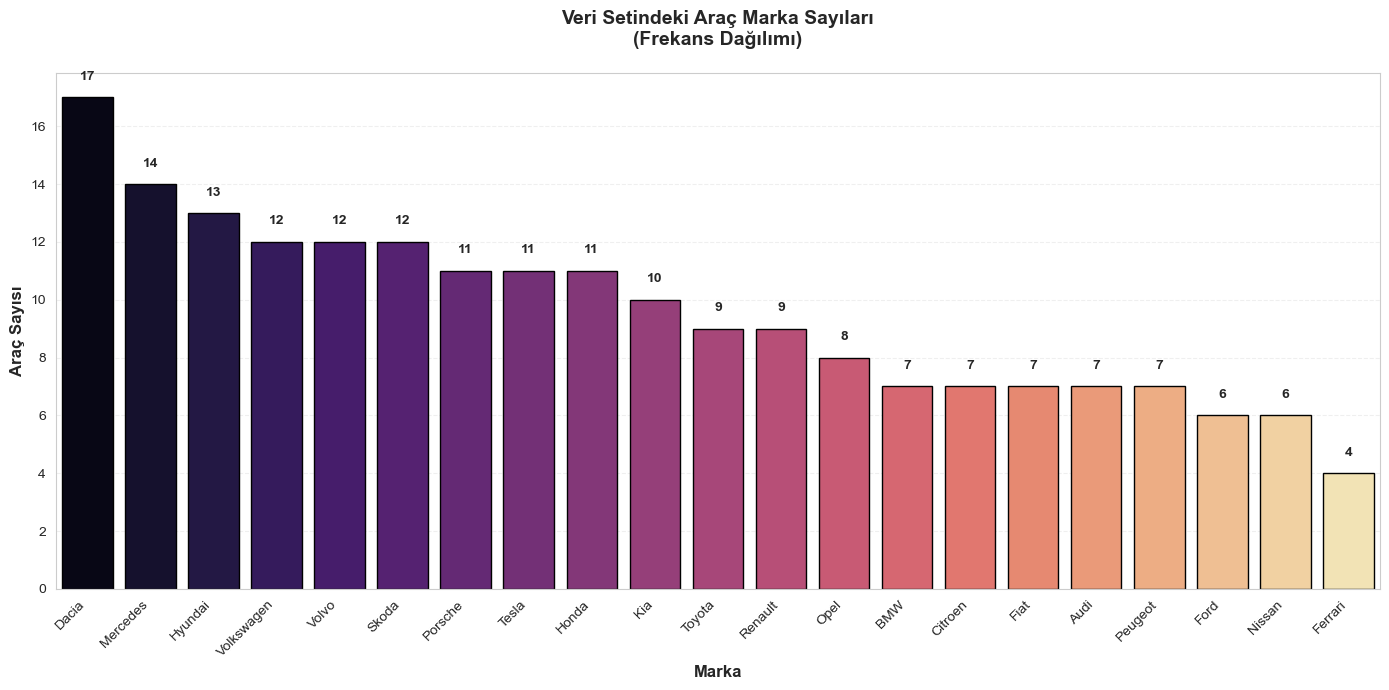


Top 5 marka:
1. Dacia: 17 araç (%8.5)
2. Mercedes: 14 araç (%7.0)
3. Hyundai: 13 araç (%6.5)
4. Volkswagen: 12 araç (%6.0)
5. Volvo: 12 araç (%6.0)


In [11]:
# ============================================
# ÖRNEK 6: Marka Sayıları (Countplot)
# ============================================

plt.figure(figsize=(14, 7))

# Marka sayılarını göster
# order parametresi ile çoktan aza doğru sıralıyoruz
# value_counts().index, en çoktan en aza doğru sıralanmış markaları verir
sns.countplot(x='Marka', data=df, 
              order=df['Marka'].value_counts().index,  # Frekansa göre sırala
              palette='magma',  # Renk paleti (turuncu-sarı tonları)
              edgecolor='black',  # Çubuk kenarları
              linewidth=1)  # Kenar kalınlığı

# Her çubuğun üzerine sayıyı ekleyelim
for i, v in enumerate(df['Marka'].value_counts().sort_values(ascending=False)):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')  # Marka isimleri sığsın diye eğiyoruz
plt.title('Veri Setindeki Araç Marka Sayıları\n(Frekans Dağılımı)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Marka', fontsize=12, fontweight='bold')
plt.ylabel('Araç Sayısı', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

marka_counts = df['Marka'].value_counts()
print(f"\nTop 5 marka:")
for i, (marka, count) in enumerate(marka_counts.head().items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {marka}: {count} araç (%{percentage:.1f})")

## 8. İki Değişkenin Detaylı Analizi (Jointplot)

### 🎯 Senaryo
**Tork** ve **Maksimum Hız** arasındaki ilişkiyi görmek istiyoruz. 
Aynı zamanda her iki değişkenin kendi dağılımlarını da görmek istiyoruz.

### 📖 Jointplot Nedir?
`jointplot`, iki değişkenin birlikte analizini yapan güçlü bir fonksiyondur. 
Bir grafikte üç farklı görselleştirme sunar:
1. **Merkez:** Scatter plot (dağılım grafiği) veya hexbin (yoğunluk haritası)
2. **Üst kenar:** X değişkeninin histogramı
3. **Sağ kenar:** Y değişkeninin histogramı

### 📊 Jointplot Türleri:
- **kind='scatter':** Klasik nokta grafiği (varsayılan)
- **kind='hex':** Altıgen petek görünümü (yoğunluk haritası)
- **kind='kde':** Yoğunluk kontur grafiği
- **kind='reg':** Regresyon doğrusu ile scatter plot
- **kind='hist':** 2D histogram

### 💡 Ne Zaman Kullanılır?
- ✅ İki değişken arasındaki ilişkiyi ve her birinin dağılımını aynı anda görmek için
- ✅ Veri yoğunluğunu görselleştirmek için (hex türü)
- ✅ Detaylı korelasyon analizi yapmak için
- ✅ Veri keşfi aşamasında hızlı analiz için

### 🔍 Yorumlama İpuçları:
- **Merkez grafik:** İki değişken arasındaki ilişkiyi gösterir
- **Kenar grafikler:** Her değişkenin tek başına dağılımını gösterir
- **Hex grafik:** Koyu renkler = yoğun veri bölgeleri
- **Pozitif eğim:** Pozitif korelasyon
- **Negatif eğim:** Negatif korelasyon

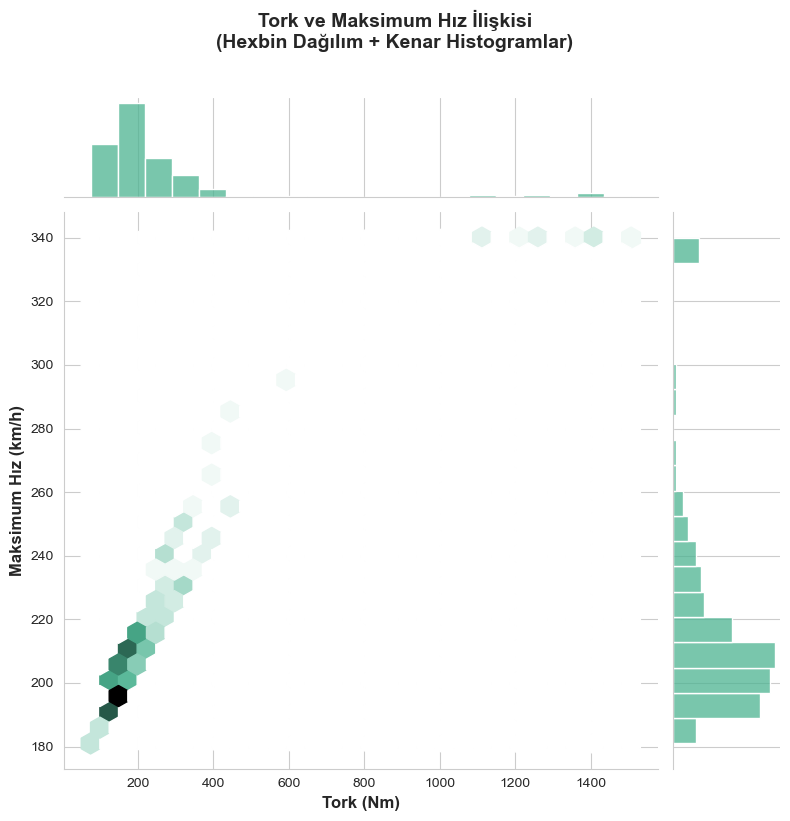

0.9470689196702577

Korelasyon: 0.947
Güçlü pozitif ilişki


In [12]:
# ============================================
# ÖRNEK 7: Tork ve Maksimum Hız İlişkisi (Jointplot)
# ============================================

# kind='hex': Noktalar yerine altıgen petek görünümü kullanır
# Verinin yoğun olduğu yerler daha koyu renk olur
# Bu sayede çok sayıda veri noktası olduğunda daha okunabilir bir grafik elde ederiz

g = sns.jointplot(x='Tork', y='Maks_Hiz', data=df, 
                  kind='hex',  # Altıgen petek görünümü
                  color='#4CB391',  # Turkuaz renk
                  height=8,  # Grafik yüksekliği
                  marginal_kws=dict(bins=20, fill=True))  # Kenar histogram ayarları

# Başlığı ayarlamak jointplot'ta biraz farklıdır
# fig.suptitle kullanılır ve y parametresi ile konumlandırılır
g.fig.suptitle('Tork ve Maksimum Hız İlişkisi\n(Hexbin Dağılım + Kenar Histogramlar)', 
               y=1.02, fontsize=14, fontweight='bold')

# Eksen etiketlerini ayarlayalım
g.set_axis_labels('Tork (Nm)', 'Maksimum Hız (km/h)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

correlation = df['Tork'].corr(df['Maks_Hiz'])
print(correlation)
print(f"\nKorelasyon: {correlation:.3f}")
if correlation > 0.7:
    print("Güçlü pozitif ilişki")
elif correlation > 0.3:
    print("Orta pozitif ilişki")
else:
    print("Zayıf ilişki")

## 📝 Ders Özeti ve Sonuçlar

### 🎓 Bu Derste Öğrendiklerimiz:

1. **lmplot**: İki sayısal değişken arasındaki ilişkiyi görselleştirme ve trend analizi
2. **boxplot**: Kategorik değişkenlere göre sayısal verilerin dağılımını analiz etme
3. **violinplot**: Veri yoğunluğunu detaylı inceleme ve dağılım karşılaştırması
4. **melt**: Veriyi uzun formata dönüştürme ve karşılaştırma için hazırlama
5. **heatmap**: Korelasyon analizi ve değişkenler arası ilişki haritası
6. **histplot**: Tek değişkenin dağılımını inceleme ve yoğunluk eğrisi
7. **countplot**: Kategorik verilerin frekansını görselleştirme
8. **jointplot**: İki değişkenin birlikte analizi (scatter + histogram kombinasyonu)

### 🔑 Önemli Noktalar:

- **Veri görselleştirme**, veri analizinin kritik bir parçasıdır
- Her grafik türü farklı bir amaca hizmet eder
- Seaborn, matplotlib'e göre daha az kod ile daha güzel grafikler oluşturur
- Grafikleri yorumlarken istatistiksel bilgileri de göz önünde bulundurmalıyız

### 🚀 Sonraki Adımlar:

- Daha fazla Seaborn fonksiyonu keşfedin (pairplot, FacetGrid, catplot vb.)
- Grafikleri özelleştirmeyi öğrenin (renkler, stiller, fontlar)
- İnteraktif görselleştirmeler için Plotly kütüphanesini deneyin
- Veri hikayesi anlatımı için görselleştirmeleri birleştirin

### 📚 Ek Kaynaklar:

- [Seaborn Resmi Dokümantasyonu](https://seaborn.pydata.org/)
- [Matplotlib Dokümantasyonu](https://matplotlib.org/)
- [Pandas Dokümantasyonu](https://pandas.pydata.org/)

